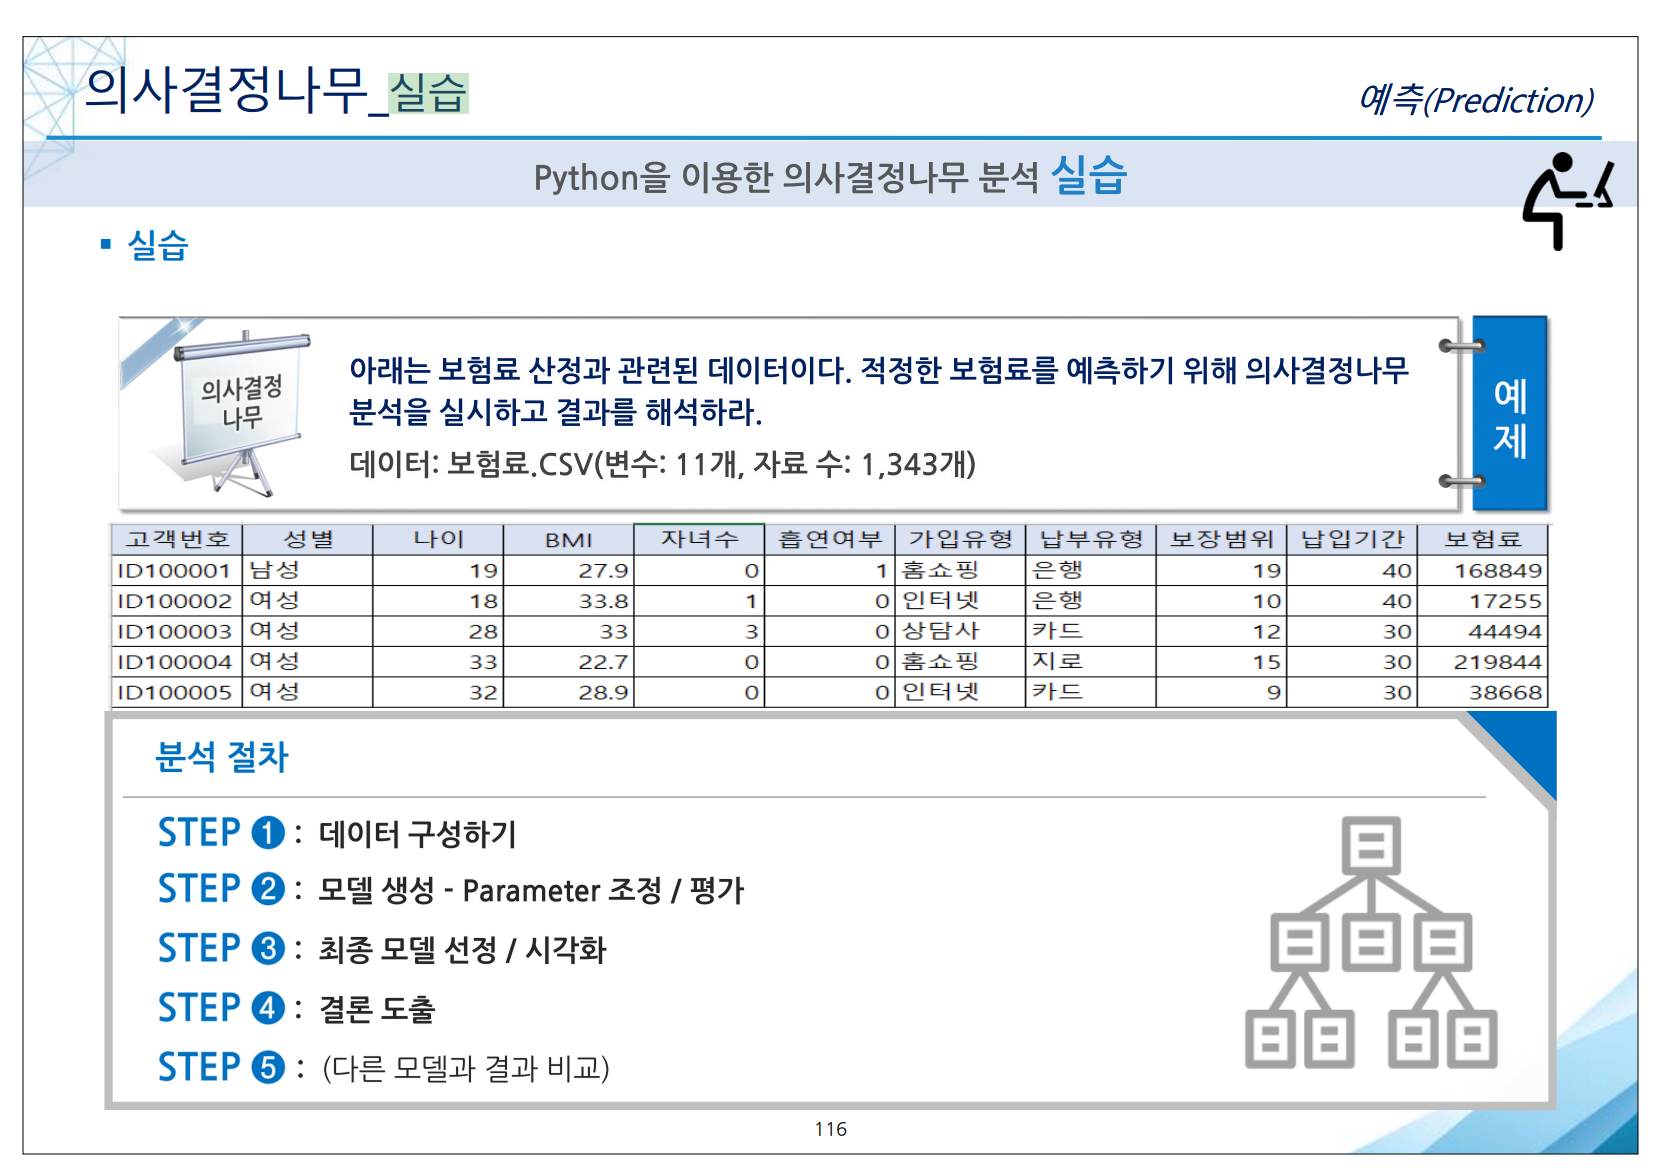

#### STEP 0 패키지 불러오기

In [1]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [2]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [3]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# export_graphviz: 나무 구조 생성 및 저장 
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Decision Tree
from sklearn.tree import DecisionTreeRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

#### STEP ❶ 데이터 구성하기

In [4]:
# 파일 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding='euc-kr')
df_raw.head()

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668


보험료를 예측하거나 분석할 때 성별, 가입유형, 납부유형을 삭제하지 않도록 하겠습니다. 고객번호는 진짜 상관 없으니 없애도록 하겠습니다.

In [5]:
# 단위를 나타내는 항목 제외
df_raw = df_raw.drop(['고객번호'], axis = 1)

In [6]:
# 범주형 변수의 Dummy 변수화
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료,성별_남성,성별_여성,가입유형_상담사,가입유형_인터넷,가입유형_홈쇼핑,납부유형_은행,납부유형_지로,납부유형_카드
0,19,27.9,0,1,19,40,168849,1,0,0,0,1,1,0,0
1,18,33.8,1,0,10,40,17255,0,1,0,1,0,1,0,0
2,28,33.0,3,0,12,30,44494,0,1,1,0,0,0,0,1
3,33,22.7,0,0,15,30,219844,0,1,0,0,1,0,1,0
4,32,28.9,0,0,9,30,38668,0,1,0,1,0,0,0,1


In [7]:
df_raw_dummy.isnull().sum()


나이          0
BMI         0
자녀수         0
흡연여부        0
보장범위        0
납입기간        0
보험료         0
성별_남성       0
성별_여성       0
가입유형_상담사    0
가입유형_인터넷    0
가입유형_홈쇼핑    0
납부유형_은행     0
납부유형_지로     0
납부유형_카드     0
dtype: int64

#### 결측치는 없음

In [8]:
# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw_dummy["보험료"]

# 설명변수(x)에는 '보험료'를 제외한 나머지 모든 컬럼을 지정
# (나머지 성별_남성, 가입유형_홈쇼핑 등 0과 1로 변한 데이터들이 다 )
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

In [9]:
# train_test_split(X: 설명변수 데이터, Y: 목표변수 데이터, test_size = test 데이터 비율, random_state: random seed)
# 가지고 있는 데이터를 공부용(Train)과 시험용(Test)으로 나누는 작업
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.3, random_state = 1234) 
print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (940, 14)
train data Y size : (940,)
test data X size : (403, 14)
test data Y size : (403,)


그냥 쉽게 생각하면   
df_train_x: 공부할 때 사용할 문제지 (나이, 성별, BMI 등 70%)

df_train_y: 공부할 때 볼 정답지 (실제 보험료 70%)

df_test_x: 모델이 얼마나 잘 맞히나 테스트할 문제지 (30%)

df_test_y: 모델이 답을 낸 후 맞춰볼 실제 정답 (30%)

### 기본 모델 만들기
#### 아무런 제약 조건 없이 나무를 무작정 성장시켜 봅니다.

In [10]:
# 기본 모델 만들기
tree_uncustomized = DecisionTreeRegressor(random_state=1234)
tree_uncustomized.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(tree_uncustomized.score(df_train_x, df_train_y)))
# test 데이터 설명력
print("Score on test set: {:.3f}".format(tree_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 1.000
Score on test set: 0.947


training set 점수: 공부한 문제로 시험을 본 점수입니다. (보통 100점에 가깝게 나옵니다.)

Test set 점수: 한 번도 본 적 없는 시험 문제로 본 점수입니다.

# 아니 근데 Test set이 이렇게 높은데 뭐하러 만들어요??

해석의 어려움: 나무가 너무 복잡하고 깊게 자라서 사람이 "도대체 어떤 기준으로 보험료를 산정한 거야?"라고 물었을 때 설명하기가 불가능해집니다.

In [11]:
tree_uncustomized.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1234,
 'splitter': 'best'}

'max_depth': None

나무의 깊이 제한이 없다는 뜻입니다. 정답을 다 맞힐 때까지 끝까지 가지를 쳤기 때문에 위에서 100점이 나온 것입니다.

'min_samples_leaf': 1

잎사귀(가장 끝 노드)에 데이터가 딱 1개만 있어도 가지를 나누었다는 뜻입니다. 아주 세세한 부분까지 파고들었다는 의미입니다.

'min_samples_split': 2

데이터가 2개만 모여도 "나눌까?" 하고 고민했다는 뜻입니다. 역시 매우 민감하게 반응했다는 증거입니다.

'criterion': 'squared_error'

가지를 나눌 때 '평균 제곱 오차'를 최소화하는 방향으로 나눴다는 뜻입니다. (회귀 모델의 표준 방식입니다.)

'random_state': 1234

우리가 지정한 암호입니다. 덕분에 다음에 돌려도 똑같은 1.000과 0.947이 나옵니다.

### 최적의 잎사귀(Leaf) 크기 찾기

In [12]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = [ ]
# min_samples_leaf: 잎사귀 최소 자료 수
para_leaf = [n_leaf for n_leaf in range(1, 20)]

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeRegressor(random_state=1234
                                 , min_samples_leaf=v_min_samples_leaf)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

# 결과 저장
df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

In [13]:
# 모델 설명력 확인
df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,1.000,0.947
1,2,0.995,0.951
2,3,0.993,0.957
3,4,0.991,0.965
4,5,0.989,0.963
5,6,0.986,0.961
6,7,0.985,0.961
7,8,0.983,0.961
8,9,0.981,0.960
9,10,0.981,0.961


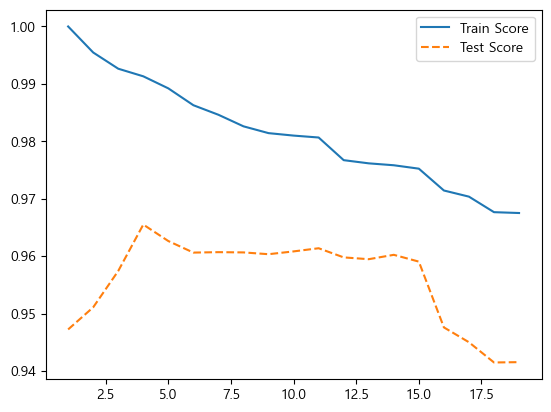

In [14]:
# 모델 설명력 그래프 확인
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.legend()

#### [정리] 하이퍼파라미터 튜닝(Hyperparameter Tuning) 결정 기준
1. 테스트 점수(Test Score)가 가장 높은 지점 선택

이유: 모델의 최종 목표는 실전(처음 본 데이터)을 잘 맞히는 것이므로, 주황색 점선(Test Score)이 최고점을 찍는 곳이 1순위 후보입니다. (일반화 성능)

2. 공부 점수와 시험 점수의 간격이 좁은 지점 선택

이유: 파란 실선(Train)과 주황 점선(Test)의 차이가 너무 크면 공부한 것만 달달 외운 과적합(Overfitting) 상태입니다. 이 간격이 적절히 좁아야 새로운 데이터에도 유연하게 대처합니다. (안정성 확보)

3. 모델의 복잡도 제어 (오컴의 면도기)

이유: 만약 성능이 비슷하다면, 너무 세세하고 복잡한 모델보다는 조금 더 단순한 모델을 선택하는 것이 미래 데이터 예측에 더 유리합니다. (단순성 유지)

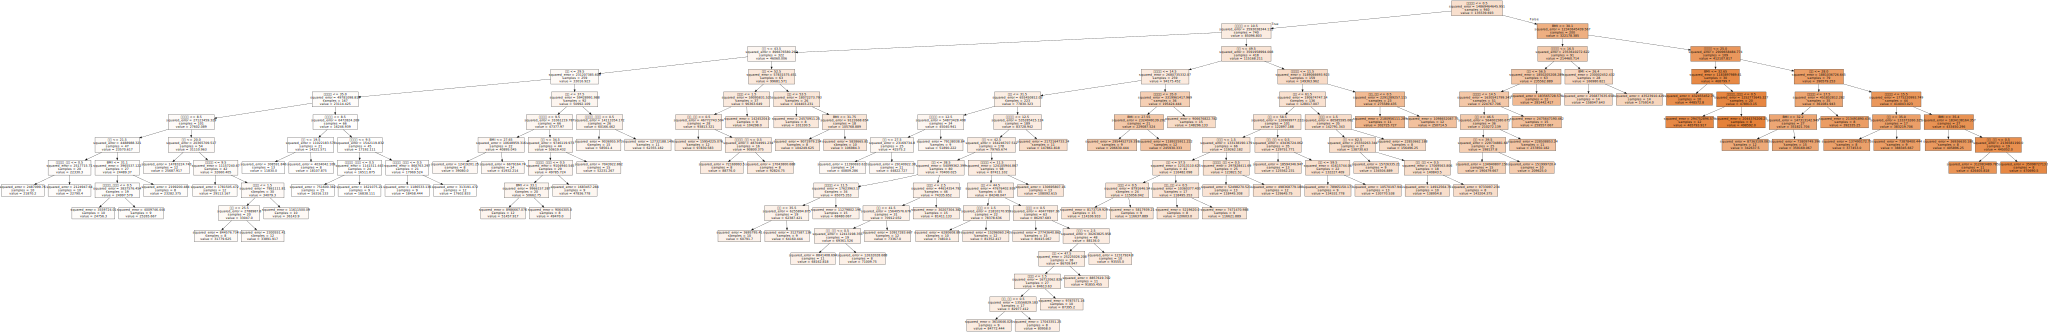

In [15]:
# 윈도우 !!!!!!!!!!!!!!!!!!!!!!!!!!!
import os
import graphviz
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeRegressor

# 윈도우 환경 변수 경로 직접 추가
# 설치 위치에 따라 'Program Files' 또는 'Program Files (x86)' 중 하나를 선택하세요.
os.environ["PATH"] += os.pathsep + 'C:/Program Files (x86)/Graphviz/bin'
# 만약 위 경로가 아니라면 아래 주석을 해제하고 사용하세요.
# os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

# ubuntu는 그냥 해도 됨
# 변수명 저장
v_feature_name = df_train_x.columns
# 노드의 최소 자료수 = 8 모델 
tree_graph = DecisionTreeRegressor(random_state=1234,  min_samples_leaf=8)
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_leaf.dot",
                feature_names = v_feature_name, impurity = True, filled = True, fontname="Malgun Gothic")       # 문자깨지면 꼭 넣기!
with open("tree_leaf.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [16]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

하이퍼파라미터 튜닝을 통해 그렸던 '그래프'를 보고 최적의 숫자(4) 결정했었음

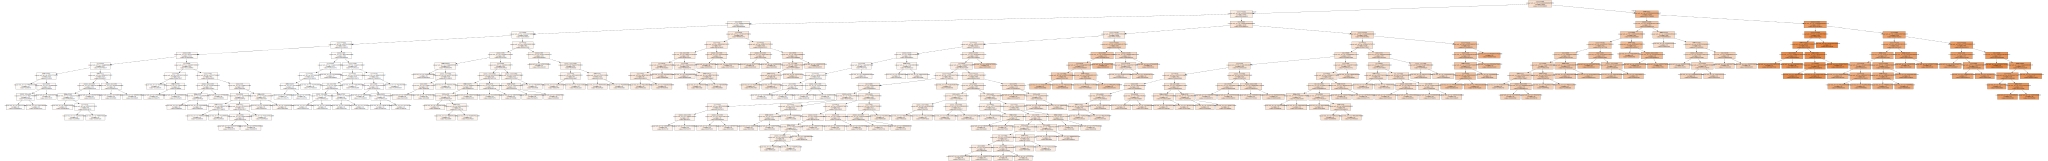

In [17]:
# 노드의 최소 자료 수=4 모델
tree_graph = DecisionTreeRegressor(random_state=1234,  min_samples_leaf=4 )
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_leaf.dot",
                feature_names = v_feature_name, impurity = True, filled = True, fontname = "Malgun Gothic")
with open("tree_leaf.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [18]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

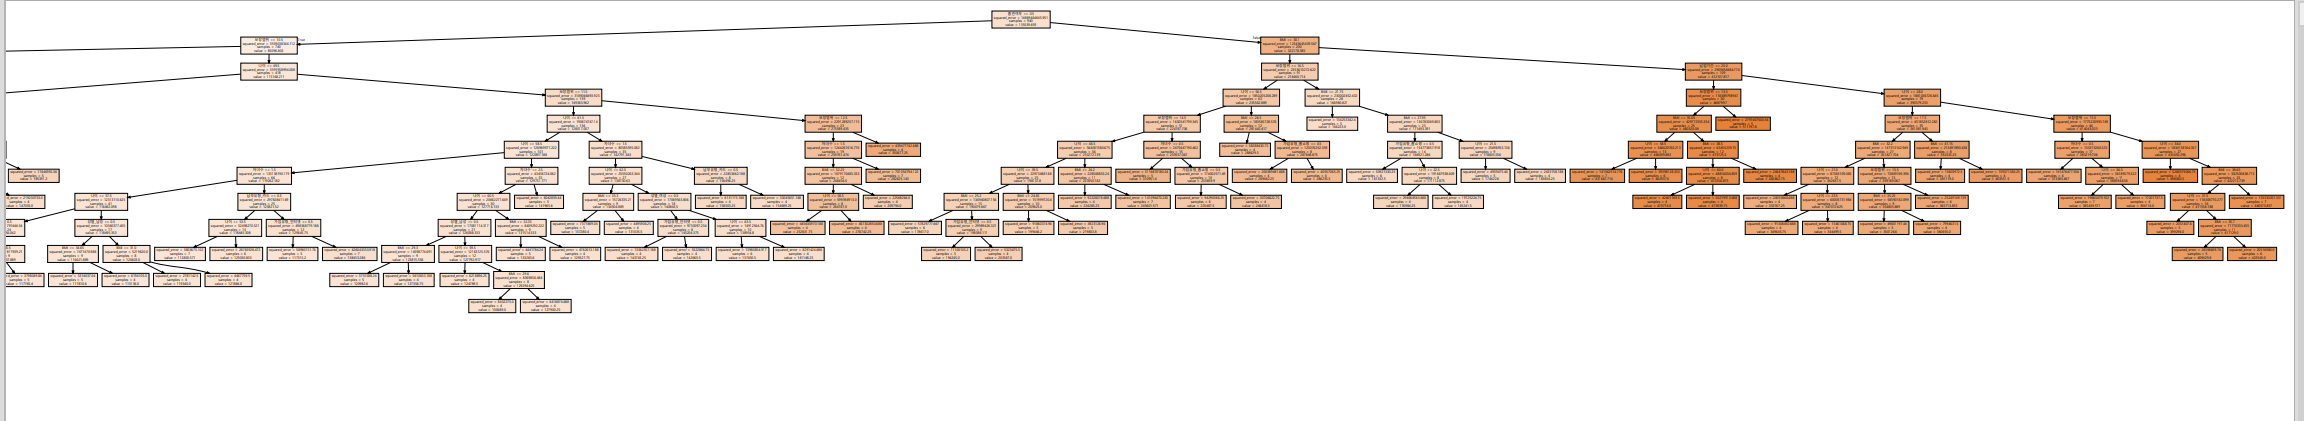

엄...청 복잡한데 이유는 4개씩 쪼개지는 과정에서 가지가 많이 생겼다. 그리고 깊이를 제한하지 않았기 때문이다.

In [19]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_split: 분리 노드의 최소 자료 수 
para_split = [n_split * 2 for n_split in range(2, 20)]

for v_min_samples_split in para_split:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4
                                 , min_samples_split=v_min_samples_split )
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

# 결과 저장
df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split  # 그래프의 X축 데이터
df_score_split["TrainScore"] = train_score      # 그래프의 Y축 데이터 (1)
df_score_split["TestScore"] = test_score        # 그래프의 Y축 데이터 (2)

In [20]:
df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore
0,4,0.991,0.965
1,6,0.991,0.965
2,8,0.991,0.965
3,10,0.991,0.966
4,12,0.990,0.967
5,14,0.989,0.968
6,16,0.987,0.967
7,18,0.986,0.966
8,20,0.986,0.966
9,22,0.985,0.966


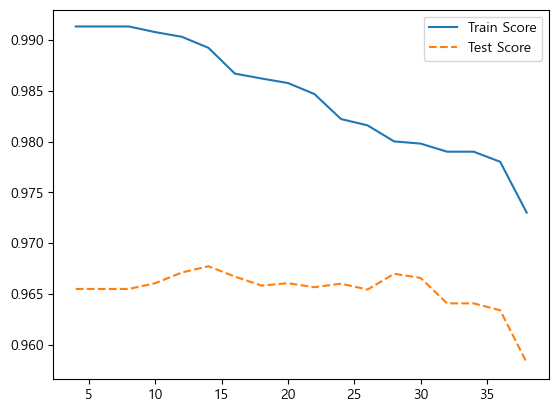

In [21]:
# 모델 설명력 그래프 확인
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.legend()

MinSamplesSplit은 쉽게 말해 "가지를 나누기 위해 필요한 최소한의 데이터 개수  
MinSamplesSplit = 14일 때, 테스트 점수가 약 0.967 정도로 가장 높습니다.    
일반화 성능: 실전 시험(Test) 점수가 가장 높은 곳이 14이므로 예측력이 가장 좋습니다.    

"적어도 14명 정도의 데이터는 모여야 보험료의 공통된 규칙을 찾을 수 있다"는 뜻입니다. 14명보다 적을 때 가지를 치면, 그건 규칙이 아니라 단순한 우연일 가능성이 크기 때문에 모델의 성능이 떨어졌던 것입니다.

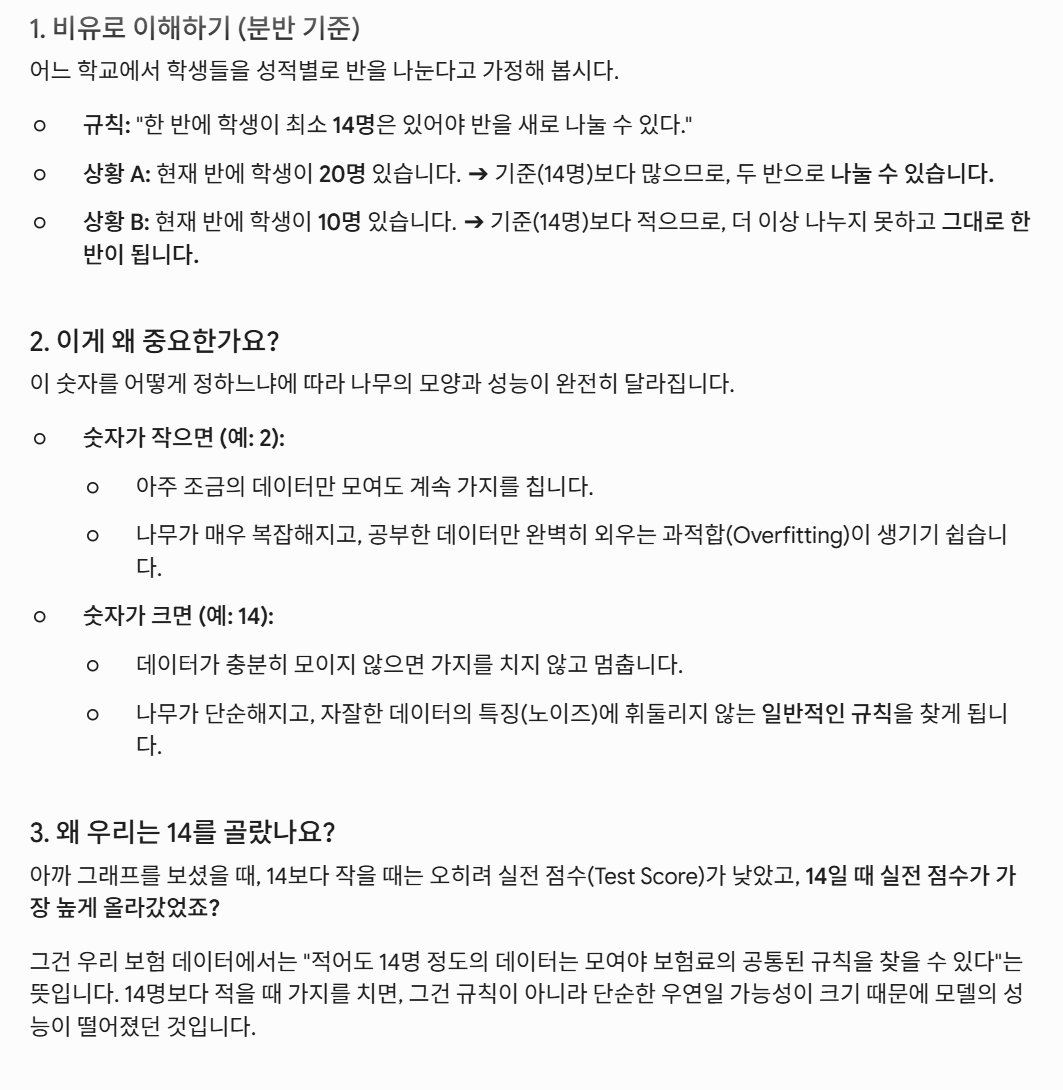

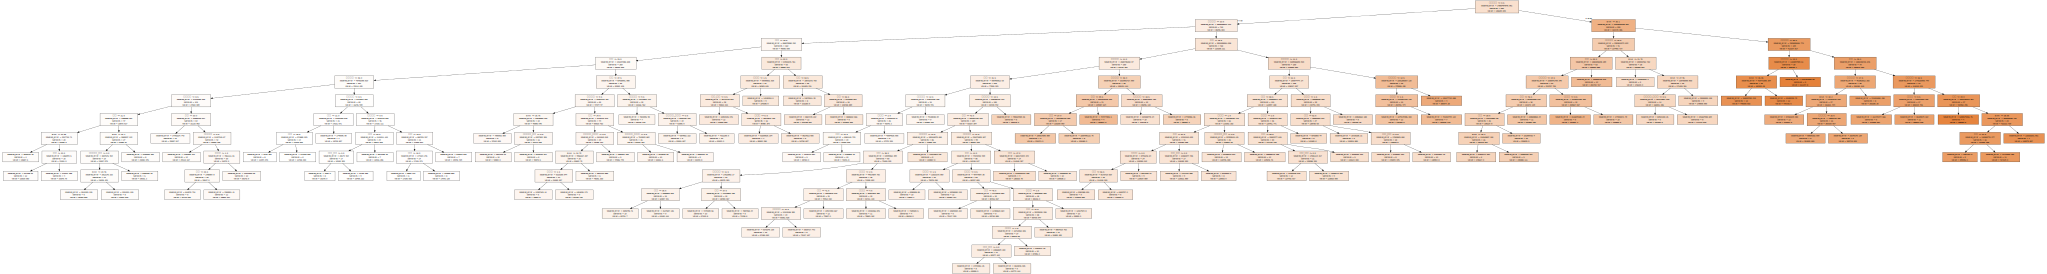

In [22]:
# 109 Page
# 분리 노드의 최소 자료 수= 20 모델
tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4, min_samples_split=14 )
tree_graph.fit(df_train_x, df_train_y)
export_graphviz(tree_graph, out_file="tree_split.dot",
                feature_names = v_feature_name, impurity = True, filled = True)
with open("tree_split.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

MSE인데 squared error로 나오는데 버전 차이래

In [24]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4, min_samples_split=14
                                  , max_depth = v_max_depth)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth            # 그래프의 X축 데이터
df_score_depth["TrainScore"] = train_score      # 그래프의 Y축 데이터 (1)
df_score_depth["TestScore"] = test_score        # 그래프의 Y축 데이터 (2)

# 결과 확인
# 모델 설명력 확인
df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.633,0.586
1,2,0.834,0.812
2,3,0.888,0.861
3,4,0.959,0.938
4,5,0.975,0.956
5,6,0.985,0.962
6,7,0.987,0.963
7,8,0.989,0.967
8,9,0.989,0.967
9,10,0.989,0.968


1. Depth가 얕을 때 (1~3 단계)
상태: 과소적합 (Underfitting)

이유: 질문을 너무 적게 던지는 상태입니다. 예를 들어 "나이가 많습니까?"라는 질문 딱 하나만 던지고 보험료를 예측하라고 하니, 데이터 속에 숨겨진 복잡한 패턴(BMI, 흡연 여부 등)을 다 파악하지 못합니다.

결과: Train과 Test 점수 모두 낮게 나옵니다. (아직 공부가 부족한 상태)

2. Depth가 적당히 깊어질 때 (4~6 단계)
상태: 성능 향상 구간

이유: "나이가 많습니까? -> 담배를 피웁니까? -> BMI가 높습니까?"처럼 질문이 구체화됩니다. 데이터의 주요 특징들을 하나씩 잡아내기 시작하면서 점수가 0.95대까지 가파르게 상승합니다.

3. Depth가 매우 깊어질 때 (7~10 단계)
상태: 정체 및 과적합 시작

이유: 이제 중요한 규칙은 다 찾아냈습니다. 8단계부터는 점수 변화가 0.967 -> 0.967 -> 0.968로 거의 없죠?

이 단계부터는 모델이 성능을 0.001이라도 더 올리려고 '의미 없는 노이즈'까지 학습하기 시작합니다.

결과 확인: Train 점수는 계속 올라가거나 유지되지만, Test 점수는 상승 폭이 멈추거나 나중에는 오히려 떨어질 수도 있습니다.

### 그래서 4임!!

#### 모델 설명력 그래프 : 나무 층수를 높일 때마다 모델의 실력이 얼마나 좋아지는지"를 보여주는 성적표

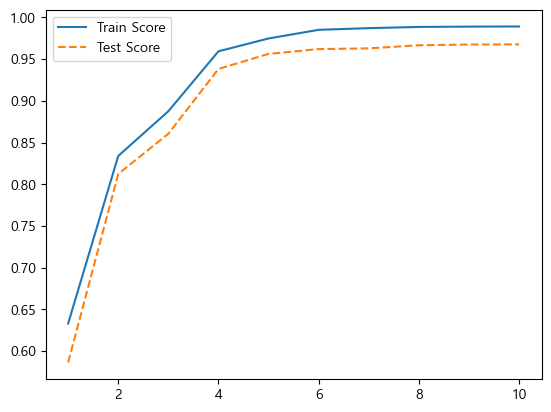

In [25]:
# 모델 설명력 그래프 확인
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.legend()

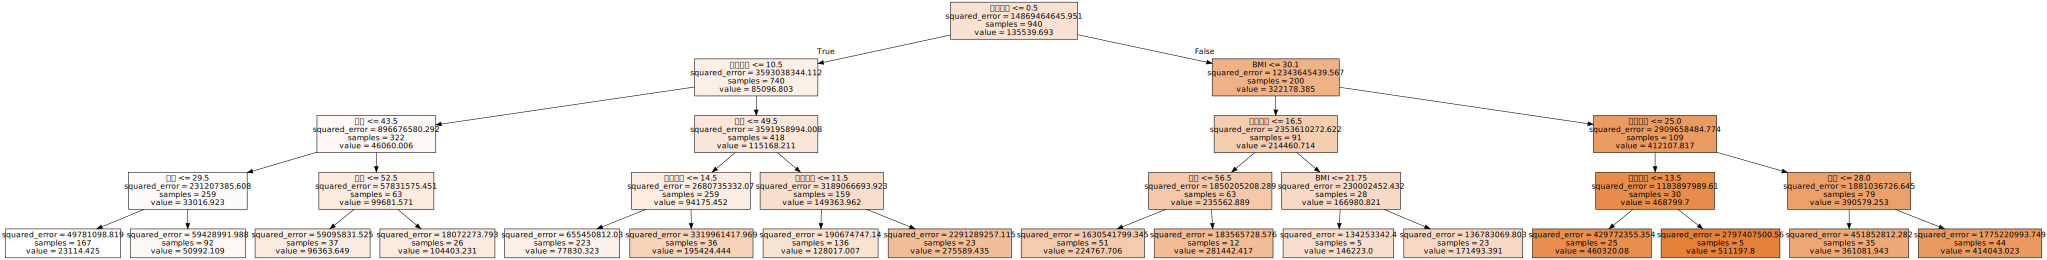

In [26]:
# 최대 깊이 = 4 모델
tree_graph = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4, min_samples_split=14, max_depth = 4 )
tree_graph.fit(df_train_x, df_train_y)

export_graphviz(tree_graph, out_file="tree_depth.dot",
                feature_names = v_feature_name, impurity = True, filled = True, fontname = "Malgun Gothic" )
with open("tree_depth.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [ ]:
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

In [27]:
v_feature_name = df_train_x.columns
tree_final = DecisionTreeRegressor(min_samples_leaf = 4, min_samples_split = 14, max_depth = 4, random_state=1234, )
tree_final.fit(df_train_x, df_train_y)
tree_final.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 4,
 'min_samples_split': 14,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 1234,
 'splitter': 'best'}

'max_depth': 4: 우리가 정한 나무의 최대 층수 4층! 잘 들어갔네요.  

'min_samples_leaf': 4: 잎사귀에 최소 4명은 있어야 한다는 규칙! 반영됐습니다.  

'min_samples_split': 14: 가지를 치려면 14명은 모여야 한다는 기준! 정확합니다.  

'random_state': 1234: 나중에 다시 돌려도 똑같은 결과가 나오게 잡아주는 고정 번호입니다.  

In [28]:
# 평가용 데이터에 대한 실제값과 예측값 확인(10개 확인)
test_pred = tree_final.predict(df_test_x)
print('test data의 실제값 : \n', df_test_y[:10])
print('test data의 예측값 : \n', test_pred[:10])

test data의 실제값 : 
 1240    472698
697     402736
324      28660
237      44632
905      45641
535      60671
945     116741
900      86888
411     195948
956     419995
Name: 보험료, dtype: int64
test data의 예측값 : 
 [460320.08       414043.02272727  23114.4251497   50992.10869565
  77830.32286996  77830.32286996 128017.00735294  77830.32286996
 224767.70588235 460320.08      ]


실제값과 예측값 비교: 실제 보험료가 높은 사람에게 모델도 높은 예측값을 주는 등 전체적인 금액의 흐름(순위)은 잘 맞히고 있습니다.

그룹별 평균 예측: 나무 깊이를 제한했기 때문에 모델이 비슷한 사람들을 하나의 그룹으로 묶어 그룹 평균값(77830 등 똑같은 숫자)으로 예측한 결과입니다.

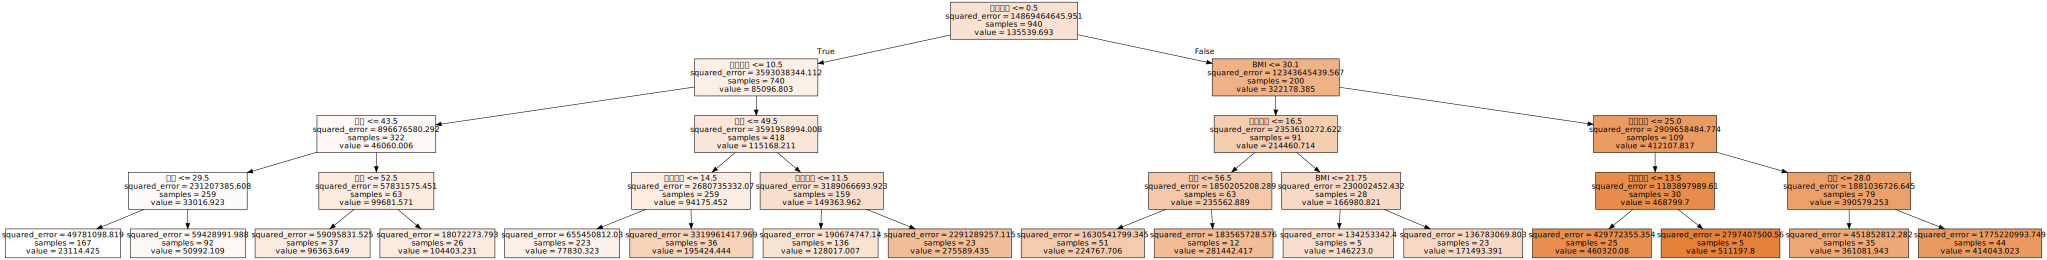

<Figure size 700x700 with 0 Axes>

In [29]:
# 최종 모델 시각화 파일 생성 (fontname 추가로 한글 깨짐 방지)
export_graphviz(tree_final, out_file="tree_final.dot",
                feature_names = v_feature_name, 
                impurity = True, 
                filled = True,
                fontname = "Malgun Gothic") # 윈도우 한글 폰트 지정

# 파일 읽기 (인코딩 설정 추가)
with open("tree_final.dot", encoding='utf-8') as f:
    dot_graph = f.read()

# 그래프 출력 (plt.figure는 생략해도 됩니다)
plt.figure(figsize = (7, 7))
display(graphviz.Source(dot_graph))

In [30]:
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = tree_final.feature_importances_

# df_feature_importance의 테이블을 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
3,흡연여부,0.660
1,BMI,0.145
4,보장범위,0.136
0,나이,0.049
5,납입기간,0.010
2,자녀수,0.000
6,성별_남성,0.000
7,성별_여성,0.000
8,가입유형_상담사,0.000
9,가입유형_인터넷,0.000


Text(0, 0.5, '변수')

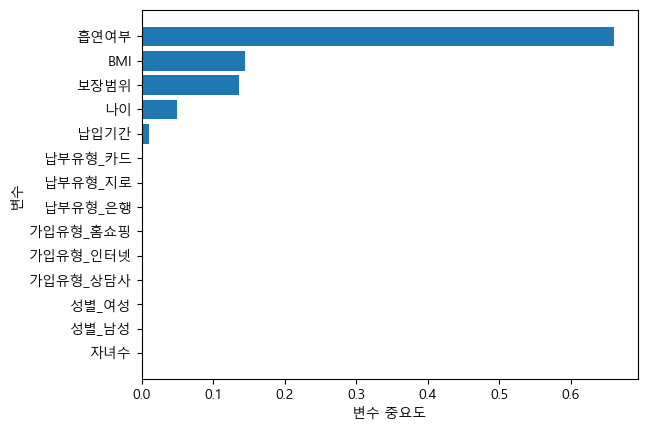

In [31]:
# 설명변수 중요도 그래프
# 중요도가 높은 변수를 상위에 그림
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

1등 ! : 흡연여부  
2등 ! : BMI, 보장범위  
3등 ! : 나이

의사결정나무 모델을 통해 변수 중요도를 분석한 결과, 흡연여부가 보험료 산출에 가장 지대한 영향을 미치는 것으로 나타났습니다. 뒤이어 BMI와 보장범위가 주요 변수로 확인된 반면, 성별이나 가입경로 등은 보험료 예측에 유의미한 영향을 주지 않는 것으로 분석되었습니다

## 이해 완!!

## 랜덤 포레스트@!!!!

데이터 전처리 → 모델 최적화(개수, 잎사귀, 깊이) → 성능 평가 → 시각화 → 변수 중요도

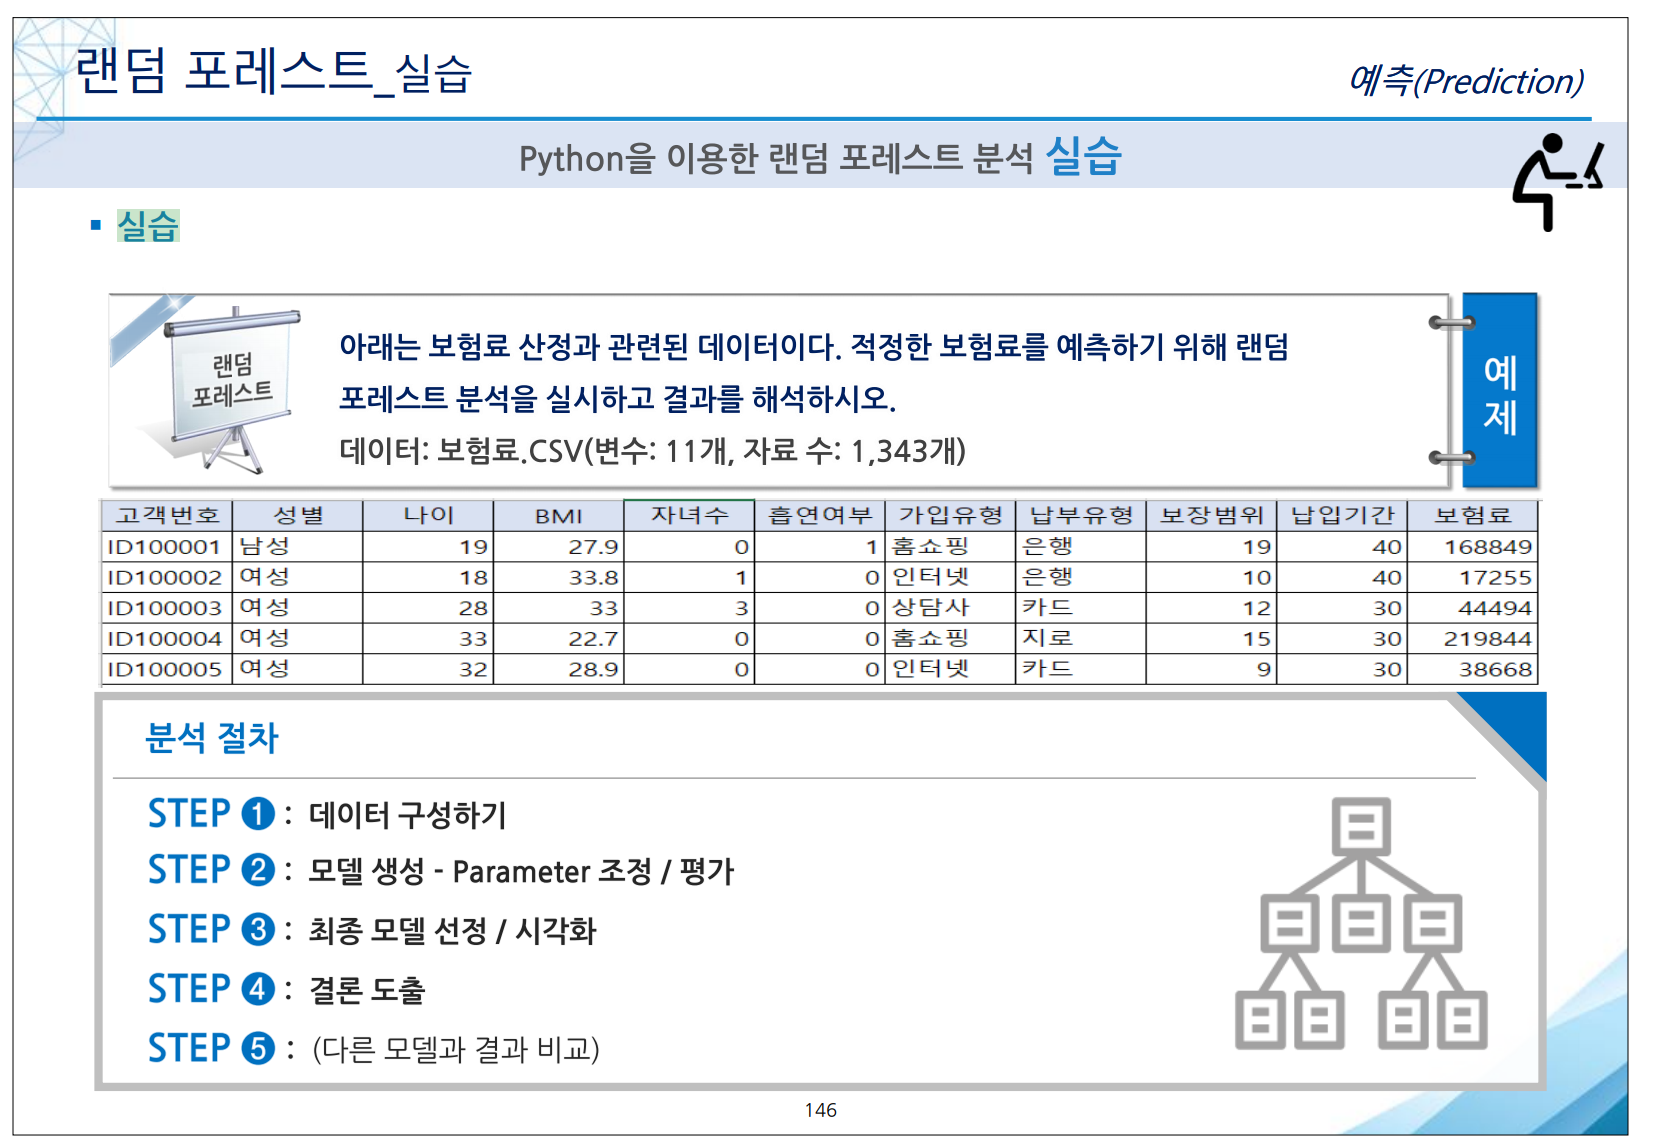

In [32]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# export_graphviz: 나무 구조 생성 및 저장 
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Random Forest
from sklearn.ensemble import RandomForestRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

In [33]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding = "euc-kr")
df_raw.head()

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668


In [34]:
# 단위를 나타내는 항목 제외
df_raw = df_raw.drop(['고객번호'], axis = 1)

In [35]:

# 범주형 변수의 Dummy 변수화
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()



,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료,성별_남성,성별_여성,가입유형_상담사,가입유형_인터넷,가입유형_홈쇼핑,납부유형_은행,납부유형_지로,납부유형_카드
0,19,27.9,0,1,19,40,168849,1,0,0,0,1,1,0,0
1,18,33.8,1,0,10,40,17255,0,1,0,1,0,1,0,0
2,28,33.0,3,0,12,30,44494,0,1,1,0,0,0,0,1
3,33,22.7,0,0,15,30,219844,0,1,0,0,1,0,1,0
4,32,28.9,0,0,9,30,38668,0,1,0,1,0,0,0,1


In [36]:
df_raw_dummy.isnull().sum()

나이          0
BMI         0
자녀수         0
흡연여부        0
보장범위        0
납입기간        0
보험료         0
성별_남성       0
성별_여성       0
가입유형_상담사    0
가입유형_인터넷    0
가입유형_홈쇼핑    0
납부유형_은행     0
납부유형_지로     0
납부유형_카드     0
dtype: int64

In [37]:
# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw_dummy["보험료"]

# 설명변수(x)에는 '보험료'를 제외한 나머지 모든 컬럼을 지정
# (나머지 성별_남성, 가입유형_홈쇼핑 등 0과 1로 변한 데이터들이 다 )
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

In [38]:
# 초기 모델 생성 및 현재 성능 확인
rf_uncustomized = RandomForestRegressor(random_state=1234)
rf_uncustomized.fit(df_train_x, df_train_y)

# Train/Test 데이터 설명력 출력
print("Score on training set: {:.3f}".format(rf_uncustomized.score(df_train_x, df_train_y)))
print("Score on test set: {:.3f}".format(rf_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 0.997
Score on test set: 0.962


1. 결과 해석 (지금 상황)  
Training Set: 0.997 (99.7%)

공부한 데이터에 대해서는 거의 100점에 가까운 완벽한 정답률을 보입니다.

Test Set: 0.962 (96.2%)

아까 의사결정나무 하나만 썼을 때(약 94~95%)보다 성능이 더 좋아졌습니다. 

In [39]:
rf_uncustomized.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 1234,
 'verbose': 0,
 'warm_start': False}

In [44]:
# n_estimators(나무 수) 변경에 따른 모델 성능 최적화
train_score = []; test_score = []
# 나무 수를 10개부터 100개까지 10단위로 증가
para_n_tree = [n_tree * 10 for n_tree in range(1, 11)]

for v_n_estimators in para_n_tree:
    rf = RandomForestRegressor(n_estimators = v_n_estimators, random_state = 1234)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 결과 저장 및 출력
df_score_n = pd.DataFrame()
df_score_n["n_estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score
df_score_n.round(3)

,n_estimators,TrainScore,TestScore
0,10,0.996,0.966
1,20,0.996,0.965
2,30,0.996,0.964
3,40,0.996,0.963
4,50,0.997,0.962
5,60,0.997,0.962
6,70,0.997,0.962
7,80,0.997,0.962
8,90,0.997,0.962
9,100,0.997,0.962


1. 결과 분석 (숫자의 의미)  
n_estimators = 10일 때: 실전 점수(TestScore)가 0.966으로 가장 높습니다.

그 이후 (20 ~ 100): 나무가 많아질수록 오히려 실전 점수가 0.962까지 아주 미세하게 떨어지면서 평평해집니다.



10	_ 0.996	 _ 0.966 !!!!!!!

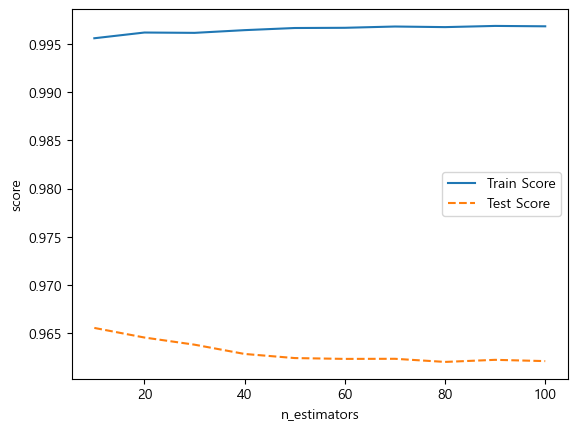

In [43]:
# 모델 설명력 그래프 확인
plt.plot(para_n_tree, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_n_tree, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("n_estimators")
plt.legend()

보통은 안정성을 위해 중간 지점을 추천하지만, 이 그래프처럼 우하향이 확실할 때는 성능과 효율을 다 챙겨야 합니다.  

최종 추천: n_estimators = 30 (또는 40)  

이유 1: 10개는 너무 초기라 운에 따를 확률이 큽니다.

이유 2: 30개 근처를 보시면 그래프의 기울기가 완만해지면서 어느 정도 안정권에 접어듭니다.

이유 3: 0.966(10개일 때)과 0.964(30개일 때)의 차이는 매우 미미합니다. 하지만 나무가 너무 많아져서 점수가 더 떨어지기 전인 30~40 지점이 가장 합리적인 타협점입니다.

### 하이퍼파라미터(min_samples_leaf) 최적화

#### 잎사귀 정하기 : 나무 100그루(n_estimators = 100)를 심은 숲에서, 각 잎사귀에 최소 1명부터 20명까지 남길 때 성적이 어떻게 변하는지 확인하는 과정

In [45]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_leaf: 잎사귀 최소 자료 수 
para_leaf = [n_leaf for n_leaf in range(1, 21)]

for v_min_samples_leaf in para_leaf:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 100,
                                min_samples_leaf = v_min_samples_leaf)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,0.997,0.962
1,2,0.994,0.964
2,3,0.991,0.967
3,4,0.988,0.966
4,5,0.985,0.964
5,6,0.983,0.962
6,7,0.981,0.961
7,8,0.980,0.961
8,9,0.978,0.960
9,10,0.977,0.958


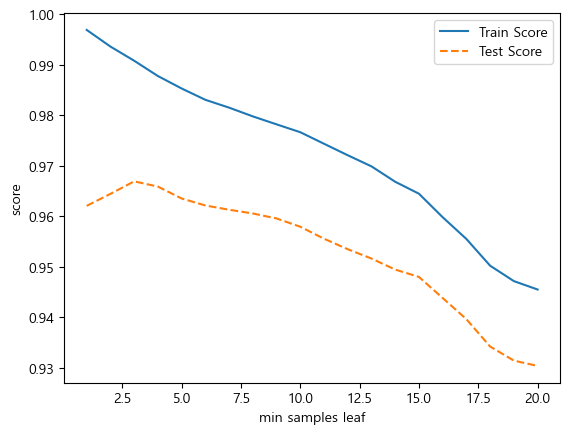

In [46]:
# 모델 설명력 그래프 확인
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

톡 튀어 나와있는 3부분으로 정하도록 하겠습니다.  
하이퍼파라미터 min_samples_leaf 최적화 결과  
테스트 데이터에 대한 예측 성능이 가장 우수(약 0.967)하며, 학습 데이터와의 오차가 적절히 제어되는 **min_samples_leaf = 3**을 최적의 파라미터로 선정함.

### 깊이 찾기

In [48]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 100,
                               min_samples_leaf = 6, min_samples_split = 14,
                               max_depth = v_max_depth)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score
df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.633,0.587
1,2,0.854,0.833
2,3,0.935,0.916
3,4,0.968,0.950
4,5,0.979,0.959
5,6,0.981,0.961
6,7,0.982,0.962
7,8,0.982,0.962
8,9,0.982,0.962
9,10,0.982,0.962


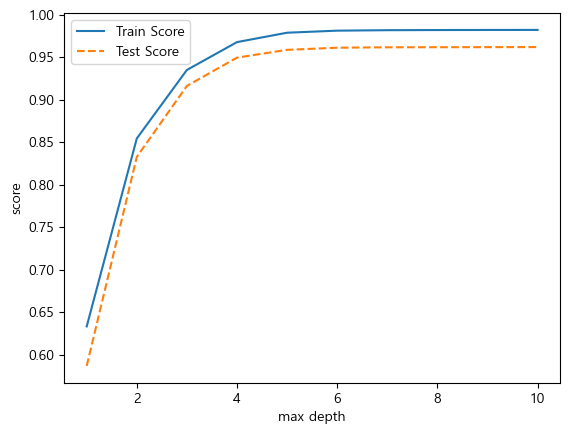

In [49]:
# 모델 설명력 그래프 확인
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("max depth")
plt.legend()

In [50]:
rf_final = RandomForestRegressor(random_state=1234, n_estimators = 100, min_samples_leaf = 6,
                                 min_samples_split = 14, max_depth = 4)
rf_final.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(rf_final.score(df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(rf_final.score(df_test_x, df_test_y)))

Score on training set: 0.968
Score on test set: 0.950


테스트 데이터 기준 약 95.0%의 예측 설명력($R^2$)을 기록함.  
학습 데이터(96.8%)와 테스트 데이터(95.0%) 간의 점수 차이가 매우 작아, 새로운 데이터에 대해서도 안정적인 성능을 보이는 우수한 일반화 모델임이 확인됨.

In [51]:
# 평가용 데이터에 대한 실제값과 예측값 확인(10개 확인)
test_pred = rf_final.predict(df_test_x)
print('test data의 실제값 : \n', df_test_y[:10])
print('test data의 예측값 : \n', test_pred[:10])

test data의 실제값 : 
 1240    472698
697     402736
324      28660
237      44632
905      45641
535      60671
945     116741
900      86888
411     195948
956     419995
Name: 보험료, dtype: int64
test data의 예측값 : 
 [474474.74141542 414054.48446915  28511.94099747  44892.6755008
  76642.51960397  74312.09157321 132238.83597816  79703.03201894
 222303.02065666 459342.09173674]


결과: 실제 472,698원 → 예측 474,474원 / 실제 402,736원 → 예측 414,054원  

비슷하다

In [52]:
# 파라미터 값 확인
rf_final.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 6,
 'min_samples_split': 14,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 1234,
 'verbose': 0,
 'warm_start': False}

max_depth: 4, min_samples_leaf: 6   

해석: 나무 깊이를 4층으로 제한하고 잎사귀 크기를 조절하여 모델을 너무 복잡하지 않게 만들었습니다.  

의미: 덕분에 95%라는 높은 안정성을 얻을 수 있었습니다.  

### '배깅(Bagging)'과 '변수 무작위 선택'을 증명

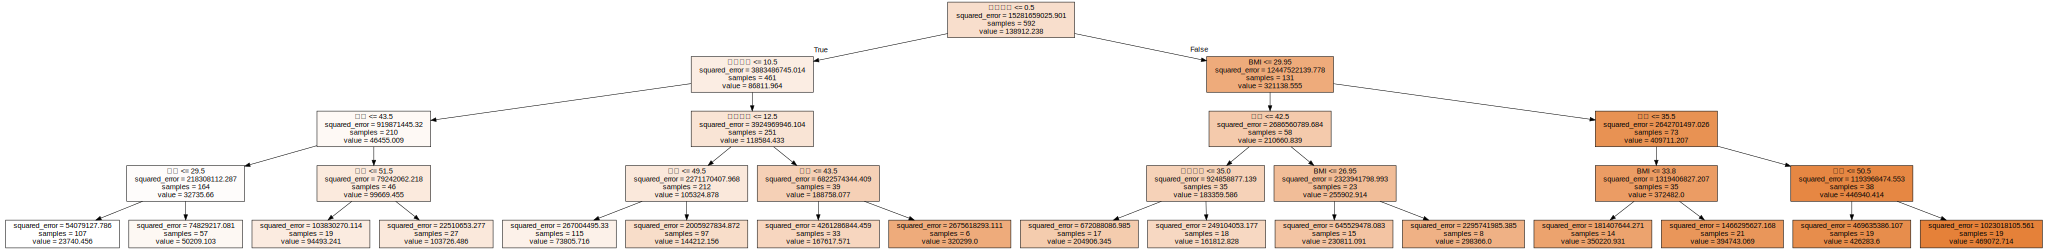

In [53]:
# 변수명 저장
v_feature_name = df_train_x.columns
# 0번 트리
export_graphviz(rf_final.estimators_[0], out_file="rfr_final_0.dot", feature_names = v_feature_name , 
                impurity = True, filled = True)
# tree_final_0.dot 그리기
with open("rfr_final_0.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

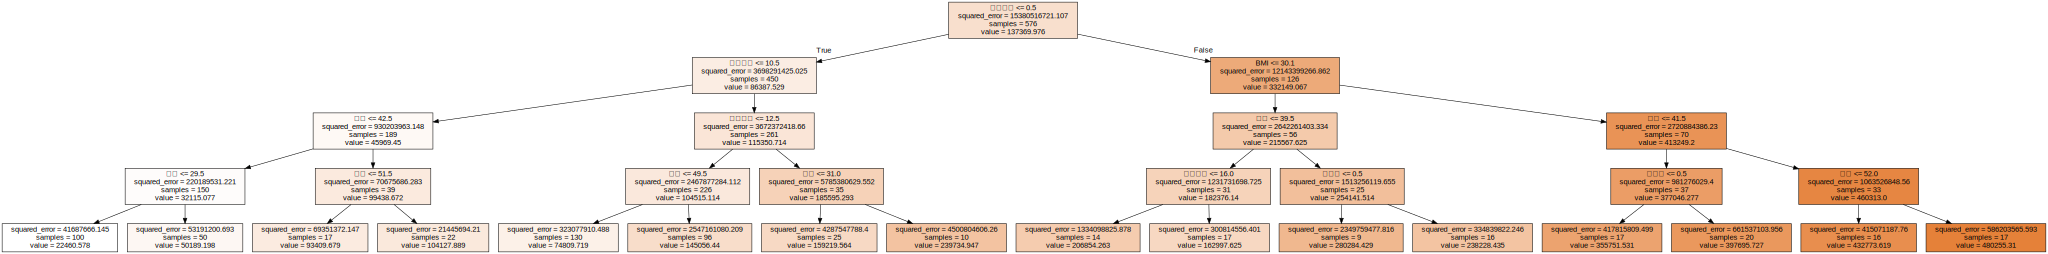

In [54]:
# 1번 트리
export_graphviz(rf_final.estimators_[1], out_file="rfr_final_1.dot", feature_names = v_feature_name , 
                impurity = True, filled = True)
# tree_final_1.dot 그리기
with open("rfr_final_1.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

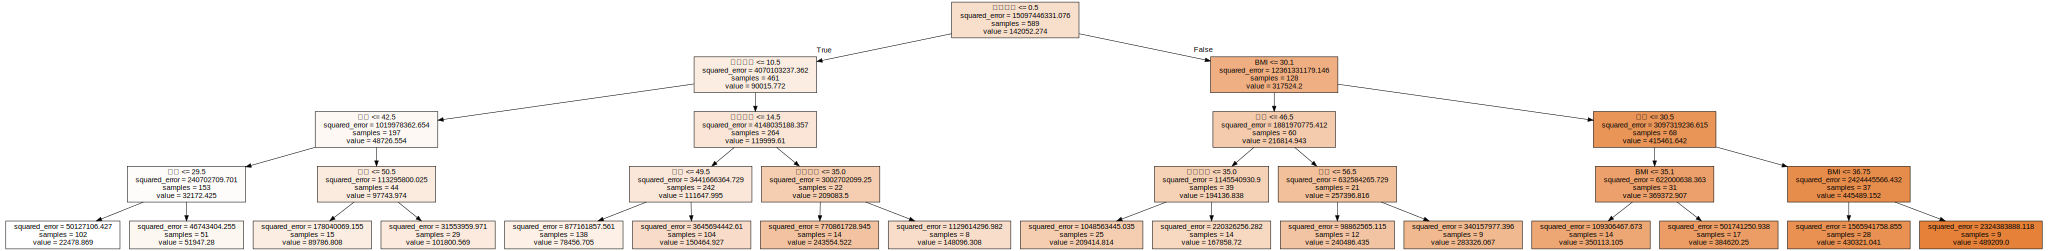

In [55]:
# 10번 트리
export_graphviz(rf_final.estimators_[10], out_file="rfr_final_10.dot", feature_names = v_feature_name, 
                impurity = True, filled = True)
# tree_final_10.dot 그리기
with open("rfr_final_10.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

In [56]:
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = rf_final.feature_importances_

# df_feature_importance의 테이블을 중요도 순으로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
3,흡연여부,0.662
1,BMI,0.147
4,보장범위,0.098
0,나이,0.075
5,납입기간,0.017
2,자녀수,0.000
6,성별_남성,0.000
7,성별_여성,0.000
9,가입유형_인터넷,0.000
8,가입유형_상담사,0.000


아예 0인 것도 존재하네요 전혀 영향을 안끼치나봅니다.

Text(0, 0.5, '변수')

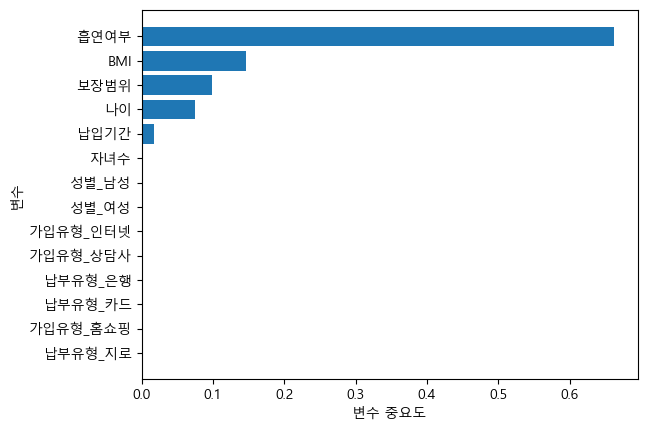

In [57]:
# 중요도가 높은 변수를 상위에 그림
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

1등 : 흡연여부  
2등 : BMI  
3등 : 보장 범위  
4등 : 나이  
5등 : 납입기간  


분석 결과, 보험료 산정에 가장 결정적인 영향을 미치는 변수는 '흡연여부'로 나타남.

뒤를 이어 BMI(체질량지수), 보장범위, 나이 순으로 높은 중요도를 보임.

성별, 가입유형, 납부유형 등은 보험료 예측에 미치는 영향력이 상대적으로 매우 낮음이 확인됨.

#### 너무 오래걸려서 패스

In [ ]:
# RandomForestRegressor라는 예측 모델의 성능을 높이기 위해 다음 세 가지 변수를 조합하며 실험하는 도구입니다.
# max_depth: 나무의 깊이 (얼마나 복잡하게 학습할 것인가)
# min_samples_split: 노드를 나누기 위한 최소 데이터 수
# min_samples_leaf: 잎 노드가 되기 위한 최소 데이터 수

# GridSearchCV를 이용한 최적 parameter 찾기
estimator = RandomForestRegressor(random_state=1234)
# 구하고자 하는 parameter와 범위
param_grid = {"max_depth": para_depth, "min_samples_split": para_split, "min_samples_leaf": para_leaf}
# 설명력이 높은 최적 parameter 찾기
grid_rf = GridSearchCV(estimator, param_grid, scoring="r2", n_jobs = -1)
grid_rf.fit(df_train_x, df_train_y)

print("best estimator model: \n{}".format(grid_rf.best_estimator_))
print("\nbest parameter: \n{}".format(grid_rf.best_params_))
print("\nbest score: \n{}".format(grid_rf.best_score_.round(3)))

KeyboardInterrupt: 

# 그래디언트부스팅

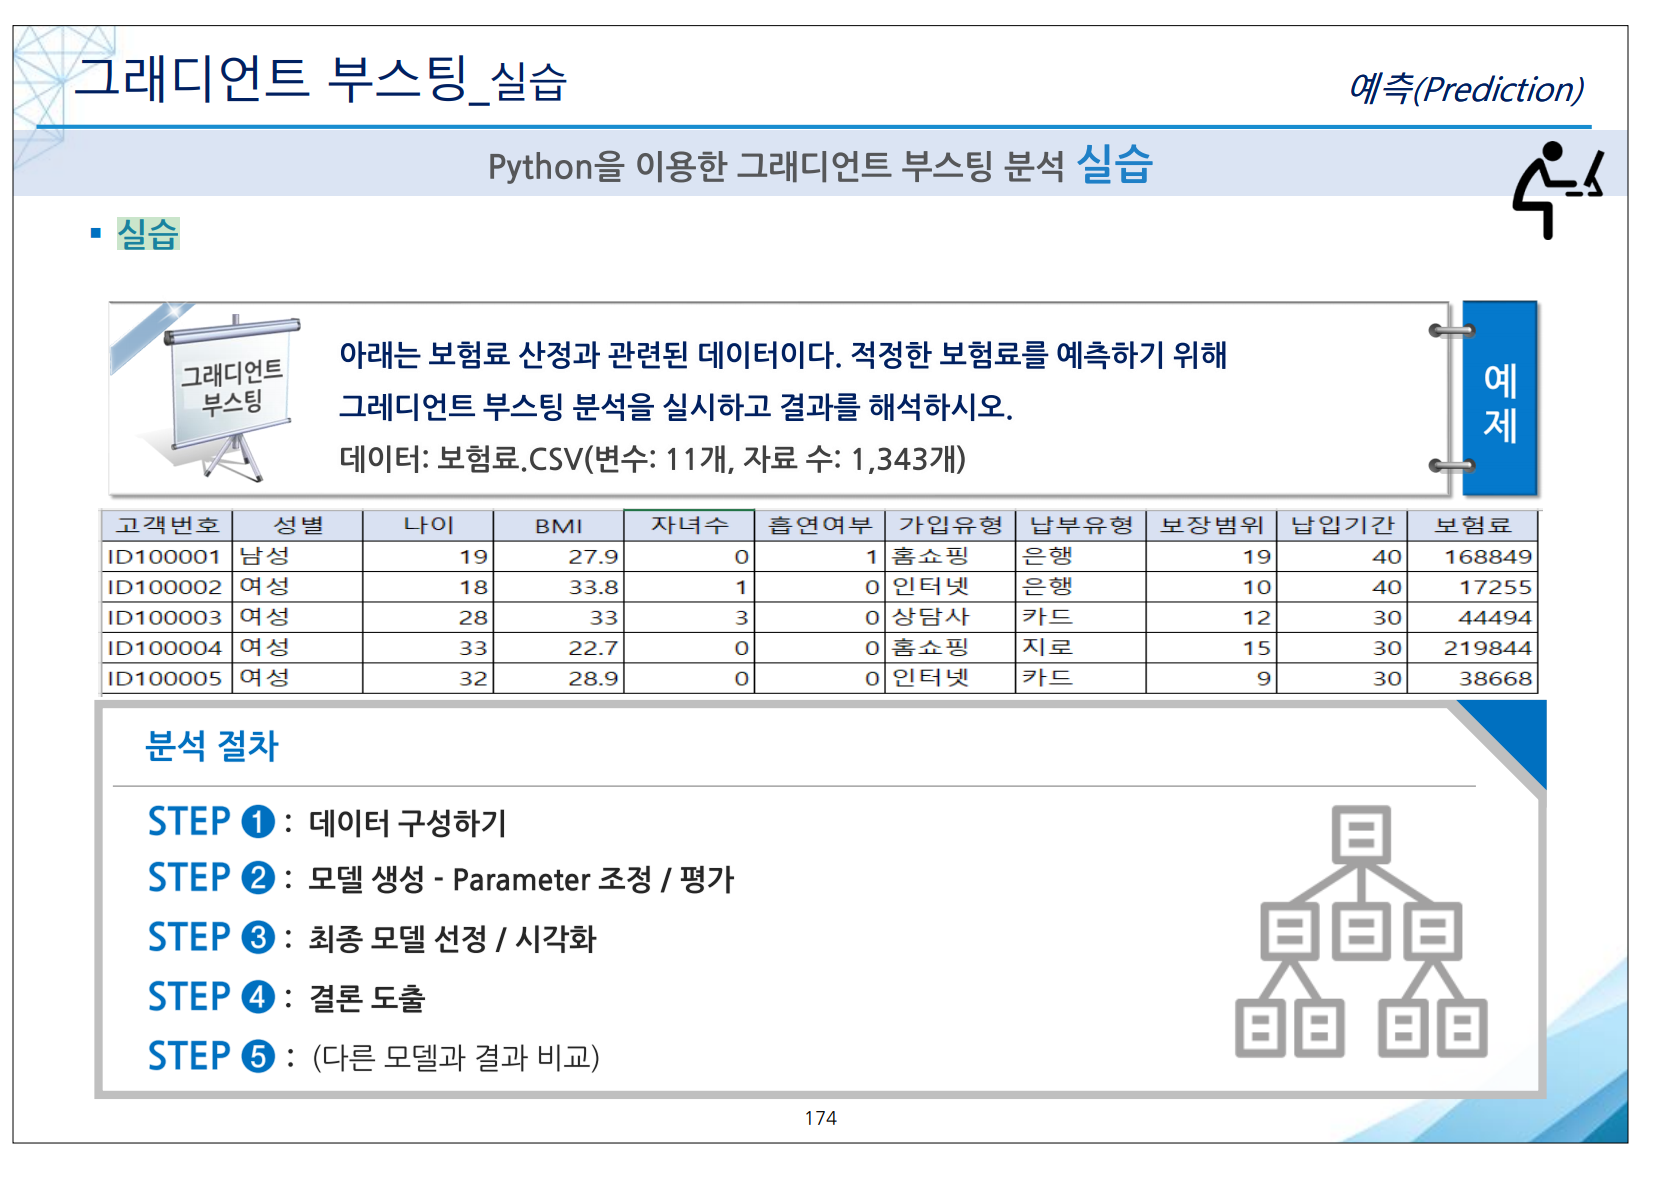

In [59]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Malgun Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [60]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [61]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

#### 그냥 위에거 긁어 왔습니다.

In [62]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding = "euc-kr")
df_raw.head()


# 단위를 나타내는 항목 제외
df_raw = df_raw.drop(['고객번호'], axis = 1)

# 범주형 변수의 Dummy 변수화
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()


df_raw_dummy.isnull().sum()


# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw_dummy["보험료"]

# 설명변수(x)에는 '보험료'를 제외한 나머지 모든 컬럼을 지정
# (나머지 성별_남성, 가입유형_홈쇼핑 등 0과 1로 변한 데이터들이 다 )
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

In [63]:
# 모델 생성: GradientBoostingRegressor
gb_uncustomized = GradientBoostingRegressor(random_state=1234)
gb_uncustomized.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(gb_uncustomized.score (df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(gb_uncustomized.score (df_test_x, df_test_y)))

Score on training set: 0.990
Score on test set: 0.963


얘도 이미 높네

In [64]:
gb_uncustomized.get_params()

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'squared_error',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 1234,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

### 그래디언트 부스팅 : 결정 트리의 총 개수를 바꿔가며 성능을 확인할거임 : '이전 트리의 오차를 다음 트리가 보완'하는 방식

#### 하이퍼파라미터 최적화 - 트리 개수(n_estimators) 변화에 따른 성능 분석

In [67]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# n_estimatos: 트리 수 변경(10~100)
para_n_tree = [n_tree * 10 for n_tree in range(1, 11)]

for v_n_estimators in para_n_tree:
    gb = GradientBoostingRegressor(random_state = 1234, n_estimators = v_n_estimators)
    gb.fit(df_train_x, df_train_y)      #학습을 시켰다 !!
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_n = pd.DataFrame()
df_score_n["Estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score

df_score_n.round(3)

,Estimators,TrainScore,TestScore
0,10,0.827,0.796
1,20,0.950,0.921
2,30,0.974,0.948
3,40,0.981,0.957
4,50,0.985,0.960
5,60,0.987,0.960
6,70,0.988,0.961
7,80,0.989,0.962
8,90,0.990,0.963
9,100,0.990,0.963


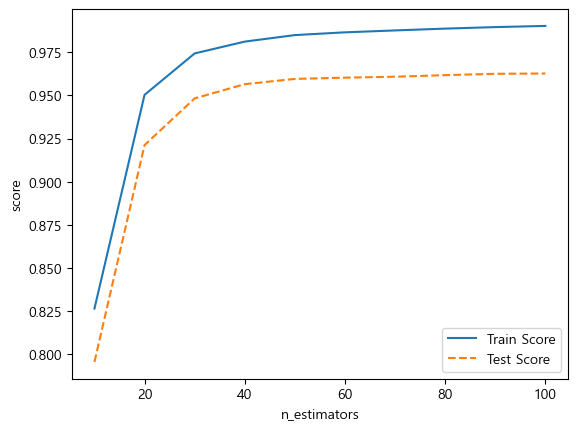

In [66]:
# 165 Page
# 모델 설명력 그래프 확인
plt.plot(para_n_tree, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_n_tree, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("n_estimators")
plt.legend()

30 부근에서 비약적으로 향상됨  
40 이후로는 정체됨  
30~50개가 연산효율적일듯  


#### n_estimators = 30

#### 하이퍼파라미터 최적화 - 잎사귀 최소 자료 수(n_min_samples_leafestimators) 변화에 따른 성능 분석

In [68]:
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_leaf: 잎사귀 최소 자료 수 
para_leaf = [n_leaf for n_leaf in range(1, 21)]

for v_min_samples_leaf in para_leaf:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30,
                                   min_samples_leaf = v_min_samples_leaf)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,0.974,0.948
1,2,0.974,0.949
2,3,0.974,0.949
3,4,0.974,0.949
4,5,0.974,0.949
5,6,0.974,0.947
6,7,0.974,0.947
7,8,0.974,0.947
8,9,0.974,0.947
9,10,0.974,0.947


In [87]:
# 168 Page
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# min_samples_split: 분할하기 위한 노드의 최소 자료 수 
para_split = [n_split * 2 for n_split in range(1, 21)]

for v_min_samples_split in para_split:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 11,
                                   min_samples_split = v_min_samples_split)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score

df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore
0,2,0.974,0.947
1,4,0.974,0.947
2,6,0.974,0.947
3,8,0.974,0.947
4,10,0.974,0.947
5,12,0.974,0.947
6,14,0.974,0.947
7,16,0.974,0.947
8,18,0.974,0.947
9,20,0.974,0.947


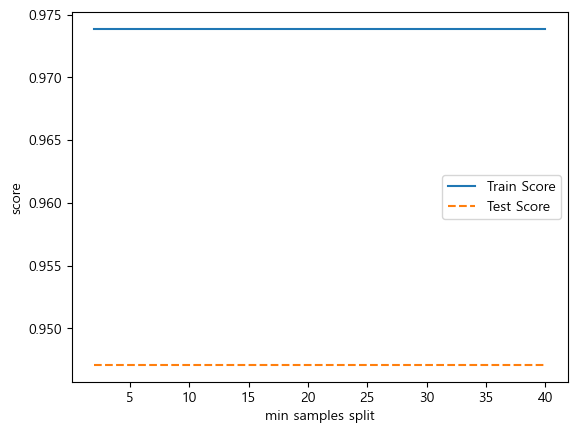

In [88]:
# 169 Page
# 모델 설명력 그래프 확인 : 22개
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples split")
plt.legend()

5개를 하든 40개로 하든 영향이 없어서 그냥 아무거나 하면 됨

잎사귀 노드의 최소 자료 수가 증가할수록 모델이 단순해져 설명력은 미세하게 감소하지만, 과적합을 방지하고 모델의 일반화 성능을 높이는 효과가 있습니다

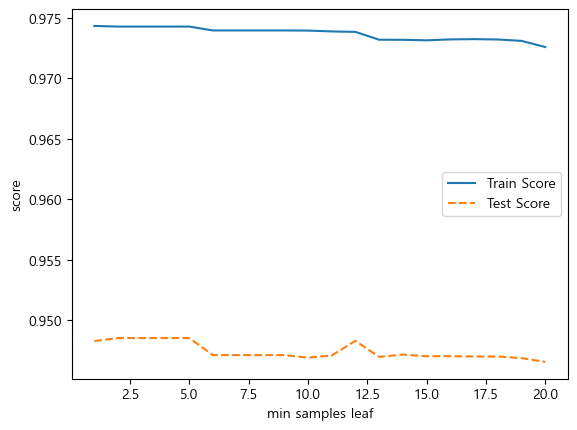

In [69]:
# 모델 설명력 그래프 확인
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

12로 정하겠ㅅ습니다ㅣ : Test Score가 국소적으로 상승하며 (빾꼼) 학습 데이터와 격차가 줄어들었으므로

### min_samples_leaf = 12

#### 하이퍼파라미터 최적화 - 트리 깊이(max_depth) 변화에 따른 성능 분석

In [77]:
# 170 Page
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 12,
                                   min_samples_split = 22, max_depth = v_max_depth)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score

df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.769,0.746
1,2,0.948,0.925
2,3,0.974,0.948
3,4,0.980,0.955
4,5,0.984,0.960
5,6,0.985,0.961
6,7,0.985,0.962
7,8,0.986,0.962
8,9,0.986,0.962
9,10,0.986,0.963


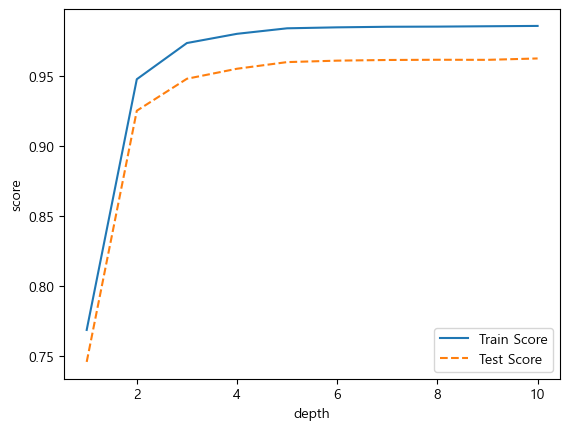

In [78]:
# 모델 설명력 그래프 확인 : 4개
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("depth")
plt.legend()

#### 트리 깊이(depth)가 깊어질수록 설명력이 급격히 향상되나, 4단계 이후로는 정체되므로 과적합 방지와 모델 효율성을 고려하여 4를 최적의 깊이로 선정합니다.

In [79]:
# 172 Page
# learning_rate: 학습률 변경에 따른 모델 성능
# train 및 test 설명력 결과 저장
train_score = []; test_score = []
# learning rate: 학습률 변경 0.1 ~ 0.9
para_lr = [lr * 0.1 for lr in range(1, 10)]

for v_learning_rate in para_lr:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 11,
                                   min_samples_split = 22, max_depth = 4, learning_rate = v_learning_rate)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

# 결과 저장
df_score_lr = pd.DataFrame()
df_score_lr["LearningRate"] = para_lr
df_score_lr["TrainScore"] = train_score
df_score_lr["TestScore"] = test_score

df_score_lr.round(3)

,LearningRate,TrainScore,TestScore
0,0.1,0.981,0.955
1,0.2,0.989,0.962
2,0.3,0.991,0.960
3,0.4,0.992,0.961
4,0.5,0.994,0.961
5,0.6,0.994,0.961
6,0.7,0.995,0.960
7,0.8,0.995,0.961
8,0.9,0.995,0.956


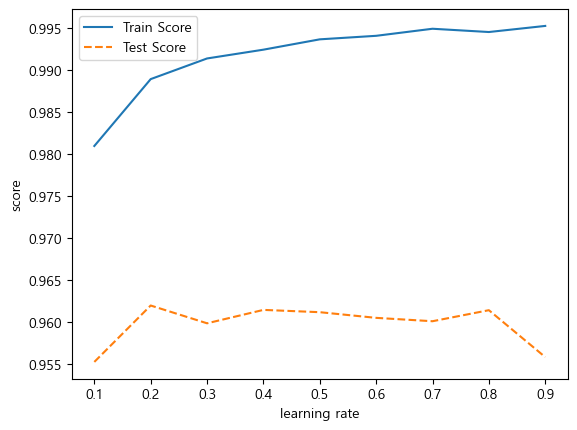

In [80]:
# 모델 설명력 그래프 확인
plt.plot(para_lr, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_lr, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("learning rate")
plt.legend()

0.2 구간: Test Score가 최고점을 찍습니다. (응용력이 가장 좋은 상태)

n_estimators: 30

max_depth: 4

min_samples_leaf: 12

learning_rate: 0.2

In [82]:
# 최종모델 선택
gb_final = GradientBoostingRegressor(random_state=1234, n_estimators = 30, min_samples_leaf = 11,
                                     min_samples_split = 22, max_depth = 4, learning_rate = 0.1)
gb_final.fit(df_train_x, df_train_y)
# Train 데이터 설명력
print("Score on training set: {:.3f}".format(gb_final.score(df_train_x, df_train_y)))
# Test 데이터 설명력
print("Score on test set: {:.3f}".format(gb_final.score(df_test_x, df_test_y)))

Score on training set: 0.981
Score on test set: 0.955


In [83]:
# 평가용 데이터에 대한 실제값과 예측값 확인(10개 확인)
test_pred =gb_final.predict(df_test_x)
print('test data의 실제값 : \n', df_test_y[:10])
print('test data의 예측값 : \n', test_pred[:10])

test data의 실제값 : 
 1240    472698
697     402736
324      28660
237      44632
905      45641
535      60671
945     116741
900      86888
411     195948
956     419995
Name: 보험료, dtype: int64
test data의 예측값 : 
 [473757.77085578 392924.34571169  32456.29207458  47095.52747326
  66684.71185337  70915.31032307 118710.61440058  87573.29607472
 204866.75283177 425095.42603602]


수치 비교: test data의 실제값(예: 472,698)과 모델의 예측값(예: 473,757)을 비교했을 때, 오차가 매우 적은 것을 확인할 수 있습니다.

In [84]:
# feature_importances_: 설명변수의 중요도
v_feature_name = df_train_x.columns

# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = gb_final.feature_importances_
# df_feature_importance의 테이블을 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
3,흡연여부,0.644
1,BMI,0.145
4,보장범위,0.115
0,나이,0.078
5,납입기간,0.016
2,자녀수,0.000
10,가입유형_홈쇼핑,0.000
7,성별_여성,0.000
12,납부유형_지로,0.000
8,가입유형_상담사,0.000


Text(0, 0.5, '변수')

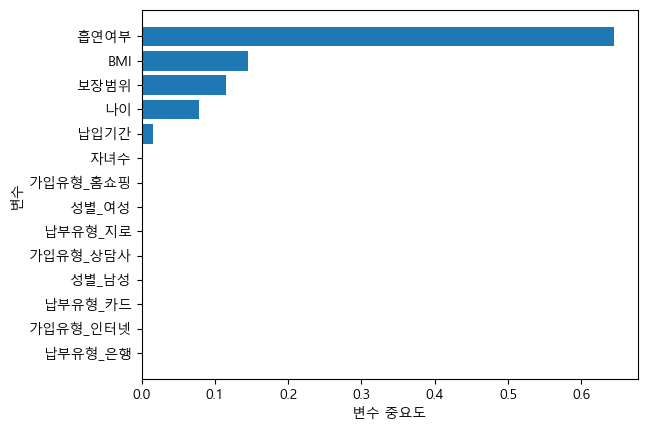

In [85]:
# 중요도가 높은 변수를 상위에 그림. 
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

### 결론

1등 : 흡연여부  
2등 : BMI  
3등 : 보장 범위  
4등 : 나이  
5등 : 납입기간  


보험료 산정에 있어 '흡연여부'가 압도적으로 가장 중요한 요인입니다  

주요 영향 변수: 그래프를 보면 흡연여부가 가장 높은 중요도를 보이며, 그 뒤를 이어 BMI(체질량지수), 보장범위, 나이 순으로 보험료 예측에 기여하고 있습니다.

비주요 변수: 반면 성별, 가입유형, 납부유형 등은 보험료 결정에 미치는 영향이 거의 없는 것으로 나타났습니다.

In [91]:
# 너무 오래 걸려요
# GridSearchCV를 이용한 최적 parameter 찾기
estimator = GradientBoostingRegressor(random_state=1234)
param_grid = {"criterion": ["mse", "friedman_mse", "mae"], "max_features": ["auto", "sqrt", "log2"], 
              "learning_rate": para_lr, "max_depth": para_depth, "min_samples_leaf": para_leaf}

grid_gb = GridSearchCV(estimator, param_grid, scoring="r2", n_jobs = -1)
grid_gb.fit(df_train_x, df_train_y)

print("best estimator model: \n{}".format(grid_gb.best_estimator_))
print("\nbest parameter: \n{}".format(grid_gb.best_params_))
print("\nbest score: \n{}".format(grid_gb.best_score_.round(3)))

KeyboardInterrupt: 

|구분|의사결정나무 (Decision Tree)|랜덤 포레스트 (Random Forest)|그래디언트 부스팅 (Gradient Boosting)|  
|------|---|---|---|
|핵심 원리|스무고개처럼 데이터를 분류|여러 개의 나무를 만들어 평균냄|이전 나무의 오차를 다음 나무가 보정|
|학습 방식|단일 모델 (Single)|병렬 학습 (Bagging)|순차적 학습 (Boosting)|
|장점|해석이 쉽고 매우 빠름|과적합 방지에 강하고 안정적|예측 성능이 가장 강력함|   
|단점|과적합(학습 데이터 집착) 심함|결과 해석이 나무보다 어려움|속도가 느리고 파라미터에 민감함|  
|비유|전문가 1명의 의견|전문가 100명의 투표|오답 노트를 쓰며 공부하는 학생|

의사결정나무는 혼자서 모든 데이터를 다 외우려다 보니 융통성이 부족해서 점수가 가장 낮다.

랜덤 포레스트는 나무 100개가 투표를 해서 결과를 내기 때문에 훨씬 안정적.

그래디언트 부스팅은 이전 나무가 틀린 걸 다음 나무가 계속 고쳐나갔기 때문에, 아주 미세한 차이(0.001점 차이!)로 랜덤 포레스트를 제치고 1등을 차지.

| 모델명 | 테스트 점수 (Test Score) | 특징 및 상태 |
| :--- | :--- | :--- |
| **의사결정나무** | 약 0.947 | 훈련 점수는 1.000이었지만 테스트 점수와 격차가 커서 **과적합**이 가장 심하다. |
| **랜덤 포레스트** | 약 0.962 | 튜닝 전 기본 모델만으로도 매우 안정적이고 높은 성능을 보여줌. |
| **그래디언트 부스팅** | **약 0.963** | 이번 실습의 주인공으로, **가장 높은 성능**을 기록하며 오차를 아주 정밀하게 잡아냄. |